# ***Import Libraries***

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ***load Dataset***

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fake_job_postings.csv.zip to fake_job_postings.csv.zip


# ***Extract ZIP***

In [ ]:
import zipfile

with zipfile.ZipFile("fake_job_postings.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("ZIP Extracted Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'fake_job_postings.csv.zip'

In [ ]:
import os
os.listdir()

# ***Load Dataset***

In [ ]:
import pandas as pd

df = pd.read_csv("fake_job_postings.csv")

# ***Check Dataset***

In [ ]:
df.head()

NameError: name 'df' is not defined

# ***Dataset shape***

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (17880, 18)


# ***Dataset Information***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

# ***Missing Values***

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


# ***Duplicate Rows***

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# ***Target Variable Distribution***

In [ ]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


Plot Target Variable

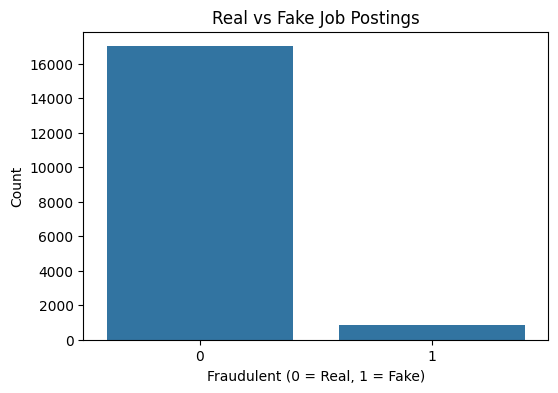

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)
plt.title("Real vs Fake Job Postings")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

# ***Statistical Summary***

In [ ]:
df.describe(include='all')

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000


# ***Fill Missing Values***

In [ ]:
# Text Columns
text_columns = [
    'title',
    'company_profile',
    'description',
    'requirements',
    'benefits'
]

for col in text_columns:
    df[col] = df[col].fillna("")


# ***Fill Categorical Columns***

In [ ]:
cat_columns = [
    'location',
    'department',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function'
]

for col in cat_columns:
    df[col] = df[col].fillna("Unknown")

# ***Drop Salary Range***

In [ ]:
df.drop("salary_range", axis=1, inplace=True)

# ***Checking Missing Value***s

In [ ]:
df.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0
has_company_logo,0


# Remove Duplicates Rows

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (17880, 17)


# ***Create One Text Column***

In [ ]:
df["text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

# ***Check***

In [ ]:
df[["text"]].head()


,text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


# ***Text Cleaning***

In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(clean_text)

# ***Check Cleaned Text***

In [ ]:
df["text"].head()

,text
0,marketing intern were food and weve created a ...
1,customer service cloud video production second...
2,commissioning machinery assistant cma valor se...
3,account executive washington dc our passion fo...
4,bill review manager spotsource solutions llc i...


# ***TF-IDF Feature Extraction***

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)


In [ ]:

X = tfidf.fit_transform(df["text"])
y = df["fraudulent"]

In [ ]:
print(X.shape)
print(y.shape)

(17880, 5000)
(17880,)


# ***Train Test Split***

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(14304, 5000)
(3576, 5000)


# ***Logistic Regression***

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr.predict(X_test)

# ***Evaluate Logistic Regression***

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.9725950782997763


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.43      0.60       173

    accuracy                           0.97      3576
   macro avg       0.99      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576



In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[3403    0]
 [  98   75]]


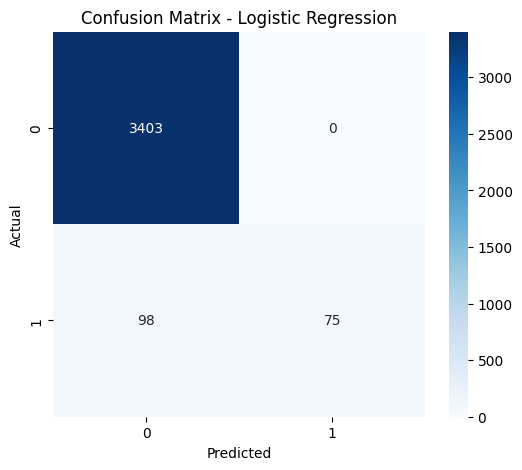

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# ***Naive Bayes***

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print(classification_report(y_test, y_pred_nb))

Accuracy: 0.9678411633109619
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.98      0.34      0.51       173

    accuracy                           0.97      3576
   macro avg       0.98      0.67      0.74      3576
weighted avg       0.97      0.97      0.96      3576



## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9714765100671141
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.72      0.66      0.69       173

    accuracy                           0.97      3576
   macro avg       0.85      0.83      0.84      3576
weighted avg       0.97      0.97      0.97      3576



# ***Random Forest***

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9798657718120806
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.58      0.74       173

    accuracy                           0.98      3576
   macro avg       0.99      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576



# ***Support Vector Machine (SVM)***

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9832214765100671
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.97      0.67      0.79       173

    accuracy                           0.98      3576
   macro avg       0.98      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576



# ***Model Comparison***

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Decision Tree',
        'Random Forest',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})

print(results)

results.sort_values(by='Accuracy', ascending=False)

                 Model  Accuracy
0  Logistic Regression  0.972595
1          Naive Bayes  0.967841
2        Decision Tree  0.971477
3        Random Forest  0.979866
4                  SVM  0.983221


,Model,Accuracy
4,SVM,0.983221
3,Random Forest,0.979866
0,Logistic Regression,0.972595
2,Decision Tree,0.971477
1,Naive Bayes,0.967841


# ***Hyperparameter Tuning (Random Forest)***

In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100],
    'max_depth': [10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'n_estimators': 100}
0.9646252796420581


# ***Save Best Model***

In [ ]:
import joblib

joblib.dump(rf, "best_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


# ***Load Model & prediction***

In [ ]:
import joblib

model = joblib.load("/content/best_model.pkl")

print("Model Loaded Successfully!")
prediction = model.predict(X_test[:5])

print("Predictions:", prediction)
print("Actual:", y_test[:5])

Model Loaded Successfully!
Predictions: [0 0 0 0 0]
Actual: 16995    0
9357     0
11561    0
1105     0
1980     0
Name: fraudulent, dtype: int64


# ***Confusion Matrix***

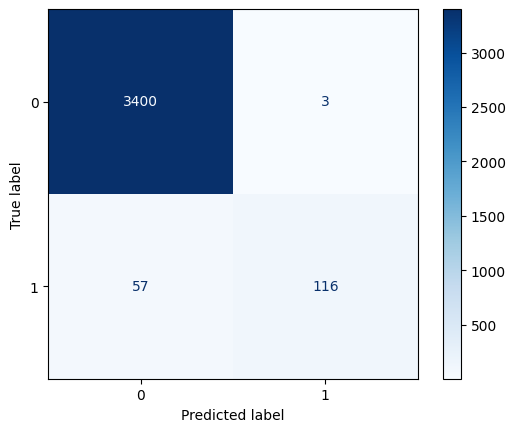

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()

# ***ROC Curve***

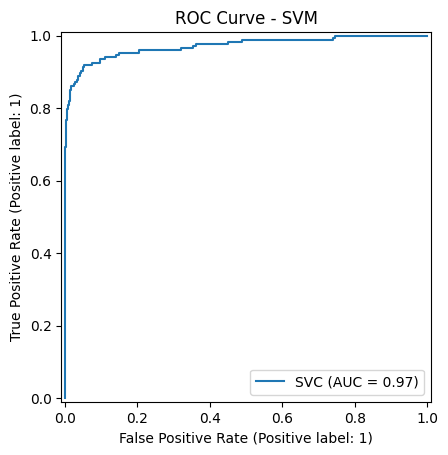

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(svm, X_test, y_test)

plt.title("ROC Curve - SVM")
plt.show()

In [ ]:
import os
import joblib

print(os.getcwd())

joblib.dump(rf, "/content/best_model.pkl")

print(os.listdir("/content"))

/content
['.config', 'fake_job_postings.csv', 'fake_job_postings.csv.zip', 'best_model.pkl', 'sample_data']
